# Stationary incompressible Navier--Stokes PINN

Comparison of three PDE residual losses:

1. MSE
2. SINOS
3. D-SINOS

The setup mirrors the Poisson PINN notebook, but the unknown is now vector-valued:

$$
(u_1,u_2,p).
$$

In [1]:
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.colors import LogNorm
from dd_discretization import DomainDecompositionDiscretization

In [2]:
# Reproducibility and device
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU is intentional: direct dense solves are more stable here.
device = torch.device("cpu")
dtype = torch.float64

RESULT_DIR = Path("results/navier_stokes_pinn")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("device:", device)
print("dtype:", dtype)
print("result directory:", RESULT_DIR)

device: cpu
dtype: torch.float64
result directory: results/navier_stokes_pinn


## Problem

We consider the stationary incompressible Navier-Stokes system

$$
-\nu \Delta u + (u\cdot \nabla)u + \nabla p = f,
\qquad
\nabla\cdot u = 0
$$

on $\Omega=(-1,1)^2$, with Dirichlet data for the velocity.

The velocity field is generated by the stream function

$$
\psi(x,y) = A \sin(\pi x)\sin(\pi y),
$$

using

$$
u = (\partial_y \psi,-\partial_x \psi).
$$

Hence $\nabla\cdot u=0$ holds exactly. We use the pressure

$$
p(x,y) = \alpha_p \sin(2\pi x + \pi y).
$$

The right-hand side is obtained by inserting $(u,p)$ into the PDE:

$$
f = -\nu \Delta u + (u\cdot \nabla)u + \nabla p.
$$

In [3]:
NU = 0.05
VEL_AMP = 1.0
P_AMP = 0.5


def exact_fields(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    pi = torch.as_tensor(np.pi, device=x.device, dtype=x.dtype)

    u1 = VEL_AMP * pi * torch.sin(pi * x1) * torch.cos(pi * x2)
    u2 = -VEL_AMP * pi * torch.cos(pi * x1) * torch.sin(pi * x2)

    p = P_AMP * torch.sin(2.0 * pi * x1 + pi * x2)

    u = torch.cat([u1, u2], dim=1)
    return u, p


def first_derivatives(s, x):
    return torch.autograd.grad(
        s,
        x,
        grad_outputs=torch.ones_like(s),
        create_graph=True,
        retain_graph=True,
    )[0]


def laplacian_scalar(s, x):
    grad_s = first_derivatives(s, x)

    s_x = grad_s[:, 0:1]
    s_y = grad_s[:, 1:2]

    s_xx = torch.autograd.grad(
        s_x,
        x,
        grad_outputs=torch.ones_like(s_x),
        create_graph=True,
        retain_graph=True,
    )[0][:, 0:1]

    s_yy = torch.autograd.grad(
        s_y,
        x,
        grad_outputs=torch.ones_like(s_y),
        create_graph=True,
        retain_graph=True,
    )[0][:, 1:2]

    return s_xx + s_yy


def navier_stokes_rhs(x):
    x = x.detach().clone().requires_grad_(True)

    u, p = exact_fields(x)
    u1 = u[:, 0:1]
    u2 = u[:, 1:2]

    grad_u1 = first_derivatives(u1, x)
    grad_u2 = first_derivatives(u2, x)
    grad_p = first_derivatives(p, x)

    u1_x = grad_u1[:, 0:1]
    u1_y = grad_u1[:, 1:2]
    u2_x = grad_u2[:, 0:1]
    u2_y = grad_u2[:, 1:2]

    p_x = grad_p[:, 0:1]
    p_y = grad_p[:, 1:2]

    lap_u1 = laplacian_scalar(u1, x)
    lap_u2 = laplacian_scalar(u2, x)

    conv1 = u1 * u1_x + u2 * u1_y
    conv2 = u1 * u2_x + u2 * u2_y

    f1 = -NU * lap_u1 + conv1 + p_x
    f2 = -NU * lap_u2 + conv2 + p_y

    return torch.cat([f1, f2], dim=1).detach()

## Discretization grid

In [4]:
# Polynomial degrees for the Gauss-Legendre tensor grid
nx, ny = 10, 10

# Number of cells in x/y direction
rx, ry = 8, 8

nbc = 2 * ry * (ny + 1) + 2 * rx * (nx + 1)

disc = DomainDecompositionDiscretization(
    polynomial_degrees=(nx, ny),
    cells_per_dim=(rx, ry),
    domain=[(-1.0, 1.0), (-1.0, 1.0)],
)
disc.init_boundary_quadrature()

pde_points = disc.points
assert pde_points.shape == (disc.N, 2)

X_pde = torch.as_tensor(pde_points, device=device, dtype=dtype)
X_bc = torch.as_tensor(disc.X_bc, device=device, dtype=dtype)

F_pde = navier_stokes_rhs(X_pde).detach()
u_bc, _ = exact_fields(X_bc)
u_bc = u_bc.detach()

W_bc = torch.as_tensor(disc.W_bc, device=device, dtype=dtype)
W = torch.as_tensor(disc.W, device=device, dtype=dtype)
Hmat_pinv = torch.as_tensor(disc.Hmat_pinv, device=device, dtype=dtype)
Hmat_pinv_s = torch.as_tensor(disc.Hmat_s_pinv, device=device, dtype=dtype)

## Network

The network has three outputs:

$$
(x,y) \mapsto (u_1(x,y),u_2(x,y),p(x,y)).
$$

In [5]:
class SinePINN(torch.nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = torch.nn.ModuleList(
            [torch.nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)]
        )
        self.reset_parameters()

    def reset_parameters(self):
        for layer in self.layers:
            torch.nn.init.xavier_uniform_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.sin(layer(x))
        return self.layers[-1](x)


def make_model():
    return SinePINN([2, 80, 80, 80, 80, 80, 3]).to(device=device, dtype=dtype)

## PDE residual

We use the residuals

$$
r_m = -\nu \Delta u_\theta + (u_\theta\cdot \nabla)u_\theta + \nabla p_\theta - f,
$$

and

$$
r_d = \nabla\cdot u_\theta.
$$

The pressure is determined only up to an additive constant. Therefore, we add a small pressure-gauge loss based on the mean pressure.

In [6]:
def pressure_gauge_mean(p):
    return torch.mean(p) ** 2


def pressure_gauge_quadrature_integral(p):
    one = torch.ones_like(p)
    value = (one.T @ W @ p).squeeze()
    return value**2


def navier_stokes_residuals(model, x, f=None):
    x = x.detach().clone().requires_grad_(True)

    out = model(x)
    u1 = out[:, 0:1]
    u2 = out[:, 1:2]
    p = out[:, 2:3]

    grad_u1 = first_derivatives(u1, x)
    grad_u2 = first_derivatives(u2, x)
    grad_p = first_derivatives(p, x)

    u1_x = grad_u1[:, 0:1]
    u1_y = grad_u1[:, 1:2]
    u2_x = grad_u2[:, 0:1]
    u2_y = grad_u2[:, 1:2]

    p_x = grad_p[:, 0:1]
    p_y = grad_p[:, 1:2]

    lap_u1 = laplacian_scalar(u1, x)
    lap_u2 = laplacian_scalar(u2, x)

    conv1 = u1 * u1_x + u2 * u1_y
    conv2 = u1 * u2_x + u2 * u2_y

    mom1 = -NU * lap_u1 + conv1 + p_x
    mom2 = -NU * lap_u2 + conv2 + p_y

    if f is None:
        f = navier_stokes_rhs(x)
    else:
        f = f.to(device=x.device, dtype=x.dtype)

    momentum_residual = torch.cat([mom1, mom2], dim=1) - f
    incompressibility_residual = u1_x + u2_y

    return momentum_residual, incompressibility_residual, p

## Losses

In [7]:
def bc_loss_mse(bc_residual):
    return torch.mean(bc_residual**2)


def bc_loss_l2(bc_residual):
    value = 0.0

    for j in range(bc_residual.shape[1]):
        r = bc_residual[:, j : j + 1]
        value = value + (r.T @ W_bc @ r).squeeze()

    return value


def pde_loss_mse(momentum_residual, incompressibility_residual):
    return (
        torch.mean(momentum_residual[:, 0:1] ** 2)
        + torch.mean(momentum_residual[:, 1:2] ** 2)
        + torch.mean(incompressibility_residual**2)
    )


def quadratic_negative_norm(r, mat):
    value = (r.T @ W @ (mat @ r)).squeeze()
    return torch.clamp(value, min=0.0)


def quadratic_l2_norm(r):
    value = (r.T @ W @ r).squeeze()
    return torch.clamp(value, min=0.0)


def make_pde_loss_sinos_like(mat, name):
    def loss(momentum_residual, incompressibility_residual):
        r_mom1 = momentum_residual[:, 0:1]
        r_mom2 = momentum_residual[:, 1:2]
        r_div = incompressibility_residual

        return (
            quadratic_negative_norm(r_mom1, mat)
            + quadratic_negative_norm(r_mom2, mat)
            + quadratic_l2_norm(r_div)
        )

    loss.__name__ = name
    return loss


pde_loss_sinos = make_pde_loss_sinos_like(Hmat_pinv, "pde_loss_sinos")
pde_loss_dsinos = make_pde_loss_sinos_like(Hmat_pinv_s, "pde_loss_dsinos")

In [8]:
def compute_losses(
    model,
    pde_loss_from_residual,
    bc_loss_from_residual,
    gauge_loss_from_pressure,
    bc_weight=1.0,
    gauge_weight=1.0,
):
    momentum_residual, incompressibility_residual, p = navier_stokes_residuals(
        model,
        X_pde,
        f=F_pde,
    )

    pde_loss = pde_loss_from_residual(
        momentum_residual,
        incompressibility_residual,
    )

    pred_bc = model(X_bc)[:, 0:2]
    bc_residual = pred_bc - u_bc
    bc_loss = bc_loss_from_residual(bc_residual)

    gauge_loss = gauge_loss_from_pressure(p)

    total_loss = pde_loss + bc_weight * bc_loss + gauge_weight * gauge_loss

    return total_loss, pde_loss, bc_loss, gauge_loss

## Evaluate solution

In [9]:
def evaluate_solution(model=None, n_eval=201):
    grid = torch.linspace(-1.0, 1.0, n_eval, device=device, dtype=dtype)

    X, Y = torch.meshgrid(grid, grid, indexing="ij")
    XY = torch.column_stack((X.reshape(-1), Y.reshape(-1)))

    with torch.no_grad():
        u_true, p_true = exact_fields(XY)

        if model is not None:
            pred = model(XY)
            u_pred = pred[:, 0:2]
            p_pred = pred[:, 2:3]

            # Align pressure constants before comparison.
            p_pred_aligned = p_pred - torch.mean(p_pred) + torch.mean(p_true)

            u_error = u_true - u_pred
            p_error = p_true - p_pred_aligned

            u_point_error = torch.linalg.norm(u_error, dim=1, keepdim=True)

            u_mse = torch.mean(u_point_error**2)
            u_rmse = torch.sqrt(u_mse)
            u_max_error = torch.max(u_point_error)

            p_mse = torch.mean(p_error**2)
            p_rmse = torch.sqrt(p_mse)
            p_max_error = torch.max(torch.abs(p_error))

            return {
                "n_eval": n_eval,
                "u_prediction": u_pred.detach().cpu().numpy(),
                "p_prediction": p_pred_aligned.detach().cpu().numpy(),
                "u_error": u_error.detach().cpu().numpy(),
                "p_error": p_error.detach().cpu().numpy(),
                "u_mse": float(u_mse.detach().cpu()),
                "u_rmse": float(u_rmse.detach().cpu()),
                "u_max_error": float(u_max_error.detach().cpu()),
                "p_mse": float(p_mse.detach().cpu()),
                "p_rmse": float(p_rmse.detach().cpu()),
                "p_max_error": float(p_max_error.detach().cpu()),
            }

    return None

## Training

In [10]:
def train_lbfgs(
    method_name,
    pde_loss_from_residual,
    bc_loss_from_residual,
    gauge_loss_from_pressure,
    base_state,
    n_iter,
    bc_weight=1.0,
    gauge_weight=1.0,
    line_search_fn="strong_wolfe",
    print_every=100,
):
    model = make_model()
    model.load_state_dict(copy.deepcopy(base_state))

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=n_iter,
        max_eval=5 * n_iter,
        history_size=50,
        line_search_fn=line_search_fn,
        tolerance_grad=1e-10,
        tolerance_change=1e-12,
    )

    history = []
    closure_calls = 0

    def make_row(closure_call):
        total_loss, pde_loss, bc_loss, gauge_loss = compute_losses(
            model,
            pde_loss_from_residual,
            bc_loss_from_residual,
            gauge_loss_from_pressure,
            bc_weight=bc_weight,
            gauge_weight=gauge_weight,
        )

        eval_result = evaluate_solution(model)

        row = {
            "method": method_name,
            "n_iter": n_iter,
            "closure_call": closure_call,
            "total_loss": total_loss.detach().item(),
            "pde_loss": pde_loss.detach().item(),
            "bc_loss": bc_loss.detach().item(),
            "gauge_loss": gauge_loss.detach().item(),
            "u_mse": eval_result["u_mse"],
            "u_rmse": eval_result["u_rmse"],
            "u_max_error": eval_result["u_max_error"],
            "p_mse": eval_result["p_mse"],
            "p_rmse": eval_result["p_rmse"],
            "p_max_error": eval_result["p_max_error"],
        }

        return total_loss, row

    def print_row(row):
        print(
            f"{method_name:8s} | "
            f"closure {row['closure_call']:04d} | "
            f"loss {row['total_loss']:.3e} | "
            f"pde {row['pde_loss']:.3e} | "
            f"bc {row['bc_loss']:.3e} | "
            f"gauge {row['gauge_loss']:.3e} | "
            f"u-rmse {row['u_rmse']:.3e} | "
            f"u-max {row['u_max_error']:.3e} | "
            f"p-rmse {row['p_rmse']:.3e}"
        )

    def closure():
        nonlocal closure_calls
        closure_calls += 1

        optimizer.zero_grad(set_to_none=True)

        total_loss, row = make_row(closure_calls)
        total_loss.backward()

        history.append(row)

        if print_every and closure_calls % print_every == 0:
            print_row(row)

        return total_loss

    optimizer.step(closure)

    return model, pd.DataFrame(history)

In [11]:
N_ITER = 2_000

base_model = make_model()
base_state = copy.deepcopy(base_model.state_dict())

model_mse, hist_mse = train_lbfgs(
    "MSE",
    pde_loss_mse,
    bc_loss_mse,
    pressure_gauge_mean,
    base_state,
    n_iter=N_ITER,
    bc_weight=1.0,
    gauge_weight=1.0,
)

model_sinos, hist_sinos = train_lbfgs(
    "SINOS",
    pde_loss_sinos,
    bc_loss_l2,
    pressure_gauge_quadrature_integral,
    base_state,
    n_iter=N_ITER,
    bc_weight=1.0,
    gauge_weight=1.0,
)

model_dsinos, hist_dsinos = train_lbfgs(
    "D-SINOS",
    pde_loss_dsinos,
    bc_loss_l2,
    pressure_gauge_quadrature_integral,
    base_state,
    n_iter=N_ITER,
    bc_weight=1.0,
    gauge_weight=1.0,
)

hist = pd.concat(
    [hist_mse, hist_sinos, hist_dsinos],
    ignore_index=True,
)

MSE      | closure 0100 | loss 1.665e+02 | pde 1.649e+02 | bc 1.545e+00 | gauge 7.218e-02 | u-rmse 3.218e+00 | u-max 6.374e+00 | p-rmse 3.587e-01
MSE      | closure 0200 | loss 6.668e+01 | pde 6.417e+01 | bc 1.825e+00 | gauge 6.862e-01 | u-rmse 4.087e+00 | u-max 6.820e+00 | p-rmse 1.260e+00
MSE      | closure 0300 | loss 1.744e+01 | pde 1.102e+01 | bc 6.409e+00 | gauge 1.158e-02 | u-rmse 4.569e+00 | u-max 7.170e+00 | p-rmse 4.806e+00
MSE      | closure 0400 | loss 4.945e+00 | pde 2.651e+00 | bc 2.292e+00 | gauge 2.839e-03 | u-rmse 2.943e+00 | u-max 5.278e+00 | p-rmse 2.901e+00
MSE      | closure 0500 | loss 1.411e+00 | pde 7.684e-01 | bc 6.420e-01 | gauge 7.008e-04 | u-rmse 1.561e+00 | u-max 3.349e+00 | p-rmse 2.136e+00
MSE      | closure 0600 | loss 5.712e-01 | pde 3.713e-01 | bc 1.999e-01 | gauge 1.021e-05 | u-rmse 1.111e+00 | u-max 2.451e+00 | p-rmse 1.873e+00
MSE      | closure 0700 | loss 2.806e-01 | pde 1.917e-01 | bc 8.889e-02 | gauge 2.464e-05 | u-rmse 7.147e-01 | u-max 1.427e+

## Benchmark summary

In [13]:
hist = pd.concat(
    [hist_mse, hist_sinos, hist_dsinos],
    ignore_index=True,
)
hist.to_csv(RESULT_DIR / "history.csv", index=True)

hist_result = pd.DataFrame(
    [
        hist_mse.iloc[-1],
        hist_sinos.iloc[-1],
        hist_dsinos.iloc[-1],
    ],
    index=["MSE", "SINOS", "D-SINOS"],
)[
    [
        "total_loss",
        "pde_loss",
        "bc_loss",
        "gauge_loss",
        "u_mse",
        "u_rmse",
        "u_max_error",
        "p_mse",
        "p_rmse",
        "p_max_error",
    ]
]

hist_result.style.format("{:.3e}")

,total_loss,pde_loss,bc_loss,gauge_loss,u_mse,u_rmse,u_max_error,p_mse,p_rmse,p_max_error
MSE,6.825e-03,5.771e-03,1.054e-03,1.978e-07,2.950e-03,5.431e-02,1.143e-01,1.586e-02,1.260e-01,3.698e-01
SINOS,3.270e-03,2.432e-03,8.380e-04,7.135e-08,1.500e-04,1.225e-02,3.044e-02,1.064e-03,3.262e-02,9.110e-02
D-SINOS,2.985e-04,2.363e-04,6.216e-05,1.146e-09,3.109e-05,5.576e-03,1.321e-02,2.646e-04,1.627e-02,5.996e-02


## Plots

In [14]:
method_order = ["MSE", "SINOS", "D-SINOS"]

plt.rcParams.update(
    {
        # Figure size / resolution
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        # Fonts
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        # Lines
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        # Axes
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        # Legend
        "legend.frameon": False,
        # Better PDF/PS font embedding
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

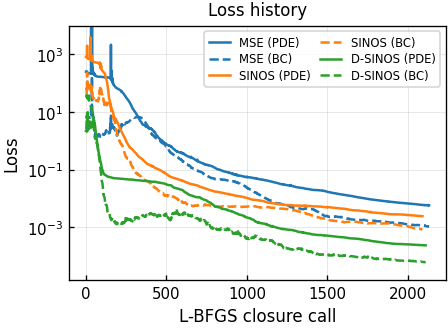

In [25]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    ax.plot(
        df["closure_call"],
        df["pde_loss"],
        color=color,
        linestyle="-",
        label=f"{method} (PDE)",
    )

    ax.plot(
        df["closure_call"],
        df["bc_loss"],
        color=color,
        linestyle="--",
        label=f"{method} (BC)",
    )

ax.set_yscale("log")
ax.set_ylim(top=10_000)
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("Loss")
ax.set_title("Loss history")
ax.grid(True, alpha=0.3)
ax.legend(
    fontsize=7,
    ncol=2,
    frameon=True,
    handlelength=1.8,
    columnspacing=0.8,
    labelspacing=0.3,
)
plt.tight_layout()
fig.savefig(RESULT_DIR / "loss_history.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()

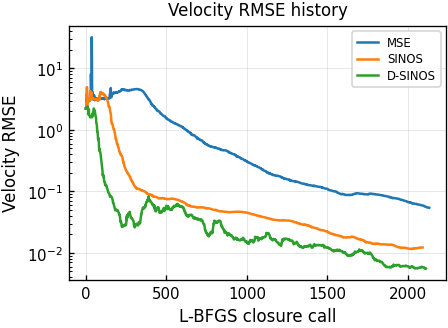

In [27]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    ax.plot(
        df["closure_call"],
        df["u_rmse"],
        color=color,
        linestyle="-",
        label=f"{method}",
    )

ax.set_yscale("log")
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("Velocity RMSE")
ax.set_title("Velocity RMSE history")
ax.grid(True, alpha=0.3)
ax.legend(
    fontsize=7,
    ncol=1,
    frameon=True,
    handlelength=1.8,
    columnspacing=0.8,
    labelspacing=0.3,
)
plt.tight_layout()
fig.savefig(RESULT_DIR / "velocity_rmse_history.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()

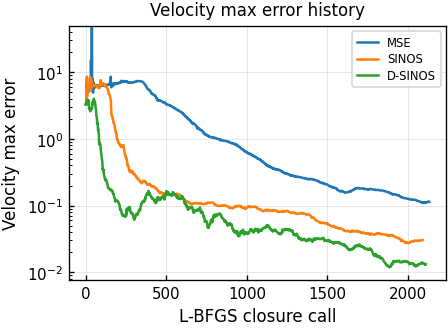

In [28]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    ax.plot(
        df["closure_call"],
        df["u_max_error"],
        color=color,
        linestyle="-",
        label=f"{method}",
    )

ax.set_yscale("log")
ax.set_ylim(top=50)
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("Velocity max error")
ax.set_title("Velocity max error history")
ax.grid(True, alpha=0.3)
ax.legend(
    fontsize=7,
    ncol=1,
    frameon=True,
    handlelength=1.8,
    columnspacing=0.8,
    labelspacing=0.3,
)
plt.tight_layout()
fig.savefig(RESULT_DIR / "velocity_max_error_history.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()

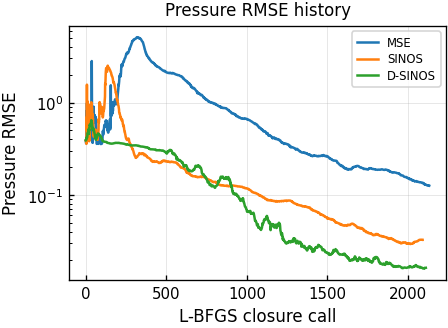

In [18]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    ax.plot(
        df["closure_call"],
        df["p_rmse"],
        color=color,
        linestyle="-",
        label=f"{method}",
    )

ax.set_yscale("log")
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("Pressure RMSE")
ax.set_title("Pressure RMSE history")
ax.grid(True, alpha=0.3)
ax.legend(
    fontsize=7,
    ncol=1,
    frameon=True,
    handlelength=1.8,
    columnspacing=0.8,
    labelspacing=0.3,
)
plt.tight_layout()
fig.savefig(RESULT_DIR / "pressure_rmse_history.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()

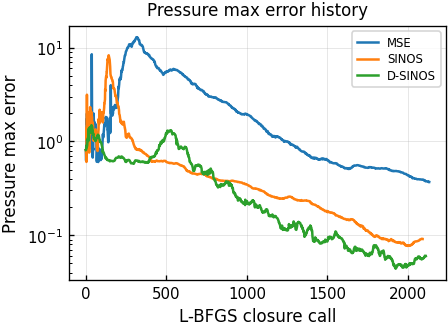

In [29]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    ax.plot(
        df["closure_call"],
        df["p_max_error"],
        color=color,
        linestyle="-",
        label=f"{method}",
    )

ax.set_yscale("log")
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("Pressure max error")
ax.set_title("Pressure max error history")
ax.grid(True, alpha=0.3)
ax.legend(
    fontsize=7,
    ncol=1,
    frameon=True,
    handlelength=1.8,
    columnspacing=0.8,
    labelspacing=0.3,
)

plt.tight_layout()
fig.savefig(
    RESULT_DIR / "pressure_max_error_history.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)
plt.show()

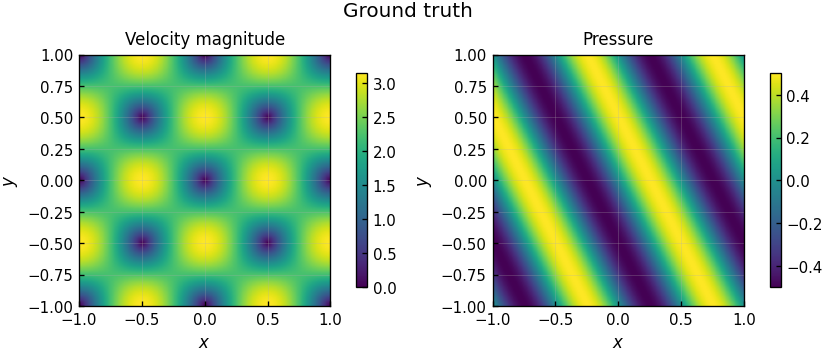

In [19]:
def plot_ground_truth(n_eval=201):
    grid = torch.linspace(-1.0, 1.0, n_eval, device=device, dtype=dtype)

    X, Y = torch.meshgrid(grid, grid, indexing="ij")
    XY = torch.column_stack((X.reshape(-1), Y.reshape(-1)))

    with torch.no_grad():
        u_true, p_true = exact_fields(XY)
        u_mag = torch.linalg.norm(u_true, dim=1).reshape(n_eval, n_eval)
        p_true = p_true.reshape(n_eval, n_eval)

    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), constrained_layout=True)

    im0 = axes[0].imshow(
        u_mag.T,
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
    )
    axes[0].set_title("Velocity magnitude")
    axes[0].set_xlabel("$x$")
    axes[0].set_ylabel("$y$")
    fig.colorbar(im0, ax=axes[0], shrink=0.85)

    im1 = axes[1].imshow(
        p_true.T,
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
    )
    axes[1].set_title("Pressure")
    axes[1].set_xlabel("$x$")
    axes[1].set_ylabel("$y$")
    fig.colorbar(im1, ax=axes[1], shrink=0.85)

    fig.suptitle("Ground truth")
    fig.savefig(RESULT_DIR / "ground_truth.pdf", format="pdf", bbox_inches="tight", dpi=600)
    plt.show()


plot_ground_truth()

In [20]:
def plot_velocity_predictions_and_errors(eval_mse, eval_sinos, eval_dsinos, eps=1e-12):
    items = [
        ("MSE", eval_mse),
        ("SINOS", eval_sinos),
        ("D-SINOS", eval_dsinos),
    ]

    n_eval = items[0][1]["n_eval"]

    velocity_magnitudes = []
    velocity_errors = []

    for _, result in items:
        u_pred = result["u_prediction"]
        u_error = result["u_error"]

        velocity_magnitudes.append(
            np.linalg.norm(u_pred, axis=1).reshape(n_eval, n_eval)
        )
        velocity_errors.append(
            np.linalg.norm(u_error, axis=1).reshape(n_eval, n_eval)
        )

    vmin_u = min(np.min(v) for v in velocity_magnitudes)
    vmax_u = max(np.max(v) for v in velocity_magnitudes)

    vmax_err = max(np.max(e) for e in velocity_errors)
    vmax_err = max(eps, vmax_err)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(8.0, 4.8),
        constrained_layout=True,
    )

    pred_im = None
    for j, (label, _) in enumerate(items):
        ax = axes[0, j]
        pred_im = ax.imshow(
            velocity_magnitudes[j].T,
            extent=[-1, 1, -1, 1],
            origin="lower",
            aspect="equal",
            vmin=vmin_u,
            vmax=vmax_u,
        )
        ax.set_title(f"{label} velocity")
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    fig.colorbar(pred_im, ax=axes[0, :], shrink=0.85)

    err_im = None
    for j, (label, _) in enumerate(items):
        ax = axes[1, j]
        abs_error = np.maximum(velocity_errors[j], eps)

        err_im = ax.imshow(
            abs_error.T,
            extent=[-1, 1, -1, 1],
            origin="lower",
            aspect="equal",
            norm=LogNorm(vmin=eps, vmax=vmax_err),
        )
        ax.set_title(f"{label} velocity error")
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    fig.colorbar(err_im, ax=axes[1, :], shrink=0.85)

    fig.suptitle("Velocity predictions and absolute errors")
    fig.savefig(
        RESULT_DIR / "velocity_predictions_and_absolute_errors.pdf",
        format="pdf",
        bbox_inches="tight",
        dpi=600,
    )
    plt.show()

In [21]:
def plot_pressure_predictions_and_errors(eval_mse, eval_sinos, eval_dsinos, eps=1e-12):
    items = [
        ("MSE", eval_mse),
        ("SINOS", eval_sinos),
        ("D-SINOS", eval_dsinos),
    ]

    n_eval = items[0][1]["n_eval"]

    pressure_predictions = []
    pressure_errors = []

    for _, result in items:
        p_pred = result["p_prediction"].reshape(n_eval, n_eval)
        p_error = np.abs(result["p_error"].reshape(n_eval, n_eval))

        pressure_predictions.append(p_pred)
        pressure_errors.append(p_error)

    vmin_p = min(np.min(p) for p in pressure_predictions)
    vmax_p = max(np.max(p) for p in pressure_predictions)

    vmax_err = max(np.max(e) for e in pressure_errors)
    vmax_err = max(eps, vmax_err)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(8.0, 4.8),
        constrained_layout=True,
    )

    pred_im = None
    for j, (label, _) in enumerate(items):
        ax = axes[0, j]
        pred_im = ax.imshow(
            pressure_predictions[j].T,
            extent=[-1, 1, -1, 1],
            origin="lower",
            aspect="equal",
            vmin=vmin_p,
            vmax=vmax_p,
        )
        ax.set_title(f"{label} pressure")
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    fig.colorbar(pred_im, ax=axes[0, :], shrink=0.85)

    err_im = None
    for j, (label, _) in enumerate(items):
        ax = axes[1, j]
        abs_error = np.maximum(pressure_errors[j], eps)

        err_im = ax.imshow(
            abs_error.T,
            extent=[-1, 1, -1, 1],
            origin="lower",
            aspect="equal",
            norm=LogNorm(vmin=eps, vmax=vmax_err),
        )
        ax.set_title(f"{label} pressure error")
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    fig.colorbar(err_im, ax=axes[1, :], shrink=0.85)

    fig.suptitle("Pressure predictions and absolute errors")
    fig.savefig(
        RESULT_DIR / "pressure_predictions_and_absolute_errors.pdf",
        format="pdf",
        bbox_inches="tight",
        dpi=600,
    )
    plt.show()

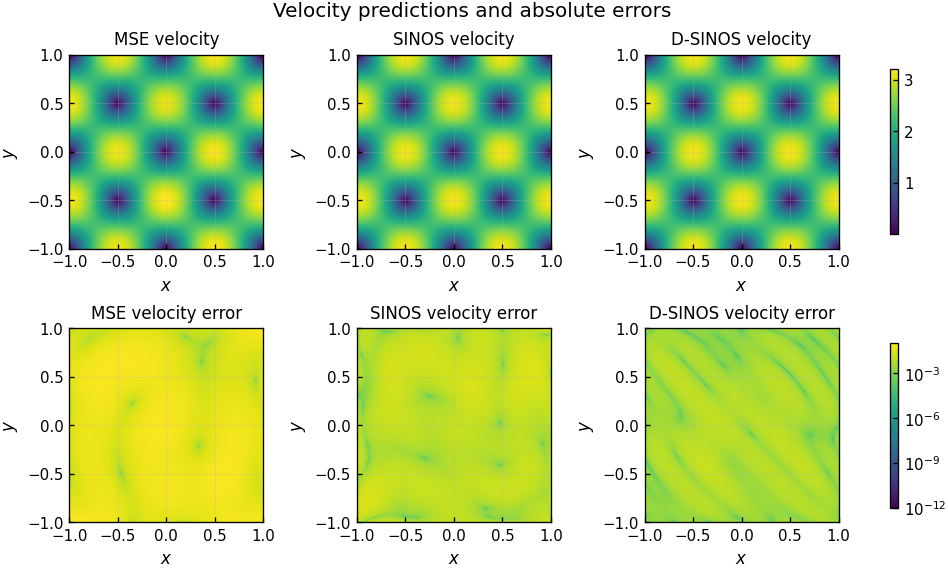

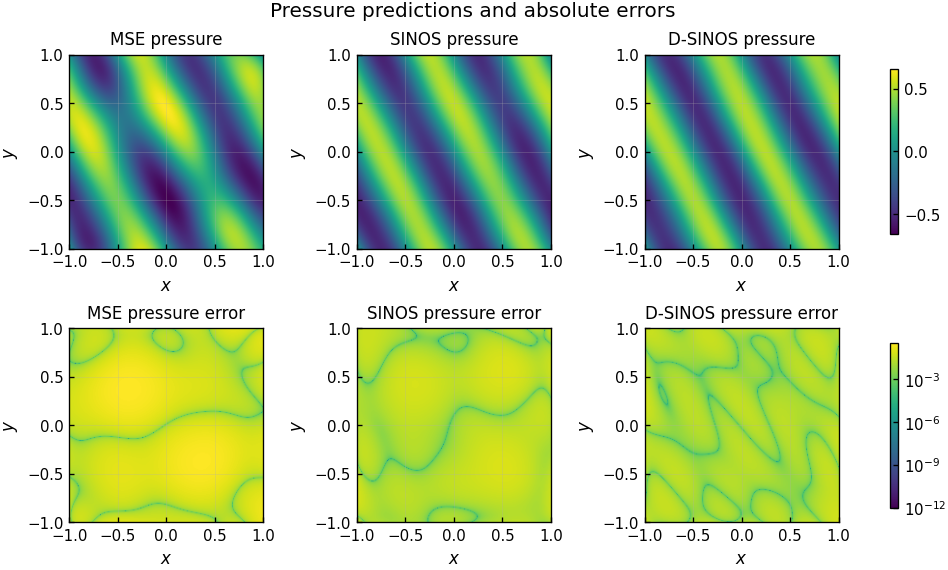

In [22]:
eval_mse = evaluate_solution(model_mse)
eval_sinos = evaluate_solution(model_sinos)
eval_dsinos = evaluate_solution(model_dsinos)

plot_velocity_predictions_and_errors(eval_mse, eval_sinos, eval_dsinos)
plot_pressure_predictions_and_errors(eval_mse, eval_sinos, eval_dsinos)